# Рубежный контроль №1 

**ФИО:** Хуан Лэй  
**Группа:** ИУ5И-22М  
**Номер варианта:** 19  
**Задачи:** №19, №39  
**Дополнительное требование:** Гистограмма

In [1]:
# 测试单元格
print("Hello, Jupyter!")
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("所有库导入成功！")

Hello, Jupyter!
所有库导入成功！


In [2]:
# 加载葡萄酒数据集
from sklearn.datasets import load_wine

wine = load_wine()

# 转换为 DataFrame
import pandas as pd
df = pd.DataFrame(wine.data, columns=wine.feature_names)
df['target'] = wine.target

# 查看数据基本信息
print("数据集形状:", df.shape)
print("\n前5行数据:")
df.head()

数据集形状: (178, 14)

前5行数据:


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0


In [13]:
# Импорт всех необходимых библиотек
# 导入所有需要的库

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_wine
from sklearn.feature_selection import SelectPercentile, mutual_info_classif

# Настройка для отображения графиков в Jupyter
# 设置让图表在Jupyter中直接显示
%matplotlib inline

# Настройка шрифтов для matplotlib (поддержка кириллицы и китайских символов)
# 设置matplotlib字体（支持俄语和中文）
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei', 'Arial Unicode MS', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

# Настройка стиля графиков
# 设置图表样式
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

print("Все библиотеки успешно загружены!")
print("所有库已成功加载！")

Все библиотеки успешно загружены!
所有库已成功加载！


In [4]:
# Загрузка набора данных Wine
# 加载葡萄酒数据集

wine = load_wine()

# Создание DataFrame с признаками
# 创建特征数据的DataFrame
df = pd.DataFrame(wine.data, columns=wine.feature_names)

# Добавление целевой переменной
# 添加目标变量
df['target'] = wine.target

# Вывод информации о данных
# 输出数据信息
print("=" * 60)
print("НАБОР ДАННЫХ: WINE DATASET")
print("数据集：葡萄酒数据集")
print("=" * 60)
print(f"Количество образцов: {df.shape[0]}")
print(f"样本数量: {df.shape[0]}")
print(f"Количество признаков: {df.shape[1] - 1} (13 признаков + 1 целевая переменная)")
print(f"特征数量: {df.shape[1] - 1} (13个特征 + 1个目标变量)")
print(f"Типы вин: {wine.target_names}")
print(f"葡萄酒类型: {wine.target_names}")
print("=" * 60)

df.head()

НАБОР ДАННЫХ: WINE DATASET
数据集：葡萄酒数据集
Количество образцов: 178
样本数量: 178
Количество признаков: 13 (13 признаков + 1 целевая переменная)
特征数量: 13 (13个特征 + 1个目标变量)
Типы вин: ['class_0' 'class_1' 'class_2']
葡萄酒类型: ['class_0' 'class_1' 'class_2']


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0


In [5]:
# ============================================================================
# ЗАДАЧА №19: Mean Normalisation (Масштабирование с помощью среднего значения)
# TASK №19: Mean Normalisation (Mean Normalization)
# ============================================================================

# Выбор произвольного числового признака для масштабирования
# 选择一个任意的数值特征进行均值归一化

# Выбираем признак 'alcohol' (алкоголь) для демонстрации
# 选择 'alcohol'（酒精含量）特征作为演示
feature_name = 'alcohol'
feature_data = df[feature_name].copy()

print("=" * 60)
print("ЗАДАЧА №19: Mean Normalisation")
print("TASK №19: Mean Normalisation")
print("=" * 60)
print(f"\nВыбранный признак: '{feature_name}'")
print(f"选择特征: '{feature_name}'")
print(f"Описание: содержание алкоголя в вине")
print(f"描述: 葡萄酒中的酒精含量")

# Статистика до нормализации
# 归一化前的统计信息
print("\n" + "-" * 40)
print("ДО НОРМАЛИЗАЦИИ / 归一化前:")
print("-" * 40)
print(f"Среднее (mean): {feature_data.mean():.4f}")
print(f"最小值 (min): {feature_data.min():.4f}")
print(f"最大值 (max): {feature_data.max():.4f}")
print(f"Стандартное отклонение (std): {feature_data.std():.4f}")

# Формула Mean Normalisation:
# X_norm = (X - mean(X)) / (max(X) - min(X))
# 均值归一化公式：X_norm = (X - 均值) / (最大值 - 最小值)

mean_val = feature_data.mean()
min_val = feature_data.min()
max_val = feature_data.max()
range_val = max_val - min_val

feature_normalized = (feature_data - mean_val) / range_val

# Статистика после нормализации
# 归一化后的统计信息
print("\n" + "-" * 40)
print("ПОСЛЕ НОРМАЛИЗАЦИИ / 归一化后:")
print("-" * 40)
print(f"Среднее (mean): {feature_normalized.mean():.4f}")
print(f"Минимум (min): {feature_normalized.min():.4f}")
print(f"Максимум (max): {feature_normalized.max():.4f}")
print(f"Стандартное отклонение (std): {feature_normalized.std():.4f}")

# Проверка свойств Mean Normalisation
# 检查均值归一化的性质
print("\n" + "-" * 40)
print("ПРОВЕРКА СВОЙСТВ / 性质验证:")
print("-" * 40)
print(f"Среднее значение после нормализации: {feature_normalized.mean():.10f} (должно быть ~0)")
print(f"归一化后的均值: {feature_normalized.mean():.10f} (应该约等于0)")
print(f"Диапазон после нормализации: [{feature_normalized.min():.4f}, {feature_normalized.max():.4f}]")
print(f"归一化后的范围: [{feature_normalized.min():.4f}, {feature_normalized.max():.4f}]")

ЗАДАЧА №19: Mean Normalisation
TASK №19: Mean Normalisation

Выбранный признак: 'alcohol'
选择特征: 'alcohol'
Описание: содержание алкоголя в вине
描述: 葡萄酒中的酒精含量

----------------------------------------
ДО НОРМАЛИЗАЦИИ / 归一化前:
----------------------------------------
Среднее (mean): 13.0006
最小值 (min): 11.0300
最大值 (max): 14.8300
Стандартное отклонение (std): 0.8118

----------------------------------------
ПОСЛЕ НОРМАЛИЗАЦИИ / 归一化后:
----------------------------------------
Среднее (mean): -0.0000
Минимум (min): -0.5186
Максимум (max): 0.4814
Стандартное отклонение (std): 0.2136

----------------------------------------
ПРОВЕРКА СВОЙСТВ / 性质验证:
----------------------------------------
Среднее значение после нормализации: -0.0000000000 (должно быть ~0)
归一化后的均值: -0.0000000000 (应该约等于0)
Диапазон после нормализации: [-0.5186, 0.4814]
归一化后的范围: [-0.5186, 0.4814]


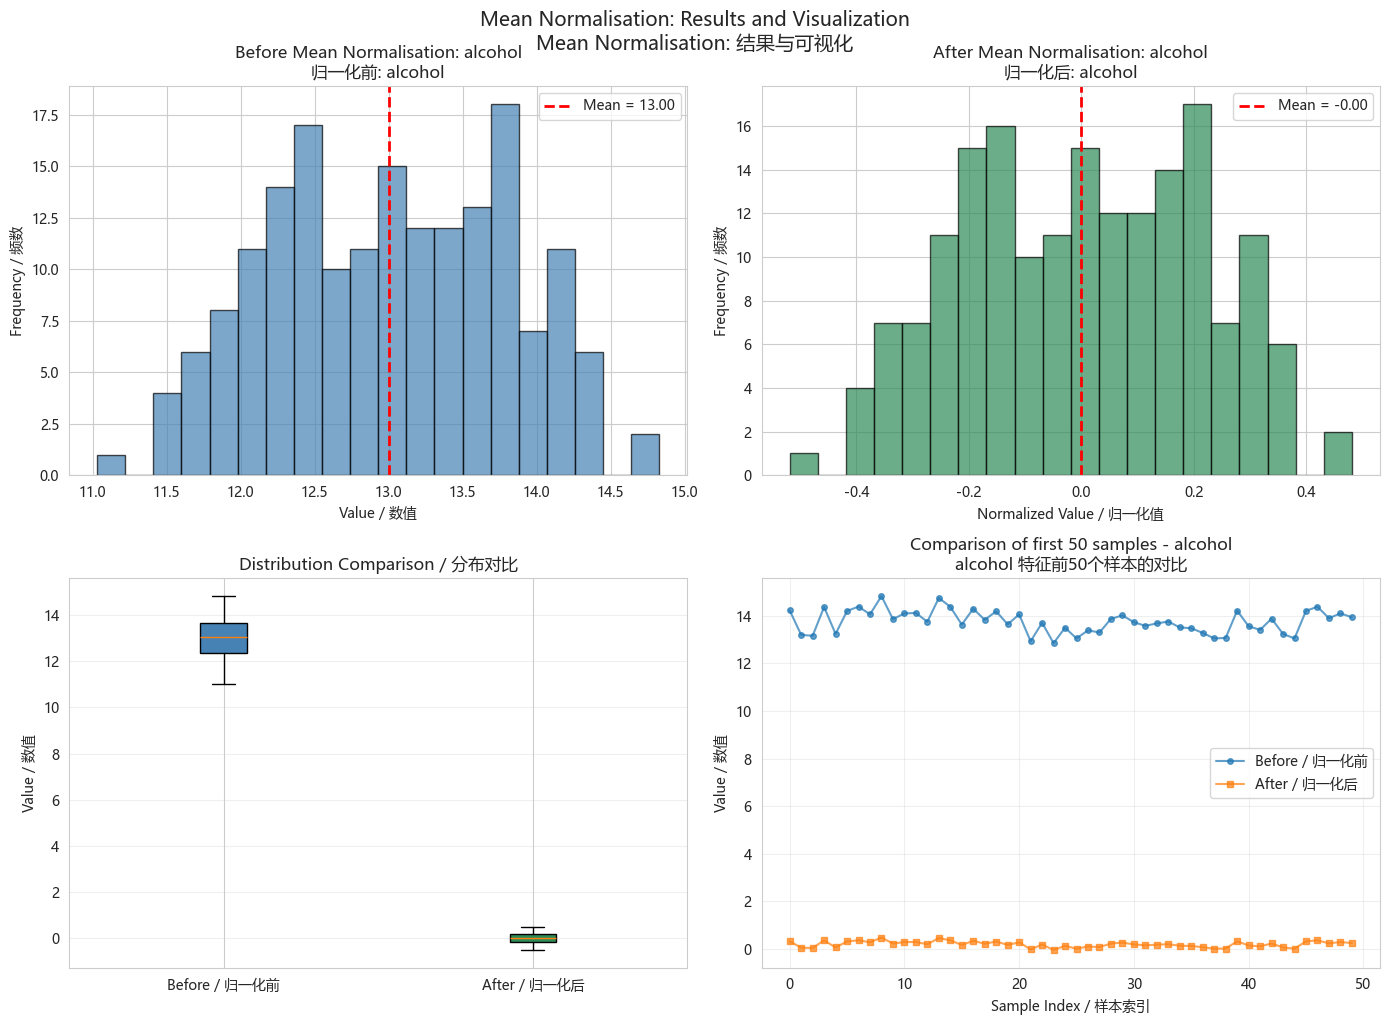


ВЫВОД ПО ЗАДАЧЕ №19 / 任务19结论:
1. Mean Normalisation преобразовал данные в диапазон от -0.5 до 0.5
   均值归一化将数据转换到了 [-0.5, 0.5] 范围内
2. Среднее значение после нормализации стало равно 0
   归一化后的均值变为0
3. Форма распределения сохранилась, но масштаб изменился
   分布的形状保持不变，但尺度发生了变化
4. Формула: X_norm = (X - mean(X)) / (max(X) - min(X))
   公式: X_norm = (X - 均值) / (最大值 - 最小值)


In [8]:
# ============================================================================
# ВИЗУАЛИЗАЦИЯ ДЛЯ ЗАДАЧИ №19 + ГИСТОГРАММА (требование для группы ИУ5И-22М)
# VISUALIZATION FOR TASK №19 + HISTOGRAM (requirement for group ИУ5И-22М)
# ============================================================================

# Настройка шрифтов для отображения китайских символов (используем Unicode fallback)
# 设置字体以显示中文（使用Unicode后备方案）
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

# Создание фигуры с тремя подграфиками
# 创建一个包含三个子图的图形

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# График 1: Гистограмма до нормализации
# Chart 1: Histogram before normalization
axes[0, 0].hist(feature_data, bins=20, color='steelblue', edgecolor='black', alpha=0.7)
axes[0, 0].set_title(f'Before Mean Normalisation: {feature_name}\n归一化前: {feature_name}', fontsize=12)
axes[0, 0].set_xlabel('Value / 数值', fontsize=10)
axes[0, 0].set_ylabel('Frequency / 频数', fontsize=10)
axes[0, 0].axvline(feature_data.mean(), color='red', linestyle='dashed', linewidth=2, label=f'Mean = {feature_data.mean():.2f}')
axes[0, 0].legend()

# График 2: Гистограмма после нормализации
# Chart 2: Histogram after normalization
axes[0, 1].hist(feature_normalized, bins=20, color='seagreen', edgecolor='black', alpha=0.7)
axes[0, 1].set_title(f'After Mean Normalisation: {feature_name}\n归一化后: {feature_name}', fontsize=12)
axes[0, 1].set_xlabel('Normalized Value / 归一化值', fontsize=10)
axes[0, 1].set_ylabel('Frequency / 频数', fontsize=10)
axes[0, 1].axvline(feature_normalized.mean(), color='red', linestyle='dashed', linewidth=2, label=f'Mean = {feature_normalized.mean():.2f}')
axes[0, 1].legend()

# График 3: Боксплот (ящик с усами) для сравнения
# Chart 3: Boxplot for comparison
# Используем tick_labels вместо labels (исправляем предупреждение Matplotlib)
# 使用 tick_labels 替代 labels (修复Matplotlib警告)
data_to_plot = [feature_data, feature_normalized]
bp = axes[1, 0].boxplot(data_to_plot, tick_labels=['Before / 归一化前', 'After / 归一化后'], patch_artist=True)
bp['boxes'][0].set_facecolor('steelblue')
bp['boxes'][1].set_facecolor('seagreen')
axes[1, 0].set_title('Distribution Comparison / 分布对比', fontsize=12)
axes[1, 0].set_ylabel('Value / 数值', fontsize=10)
axes[1, 0].grid(axis='y', alpha=0.3)

# График 4: Линейный график сравнения значений
# Chart 4: Line chart comparing original and normalized values
axes[1, 1].plot(feature_data.values[:50], 'o-', label='Before / 归一化前', alpha=0.7, markersize=4)
axes[1, 1].plot(feature_normalized.values[:50], 's-', label='After / 归一化后', alpha=0.7, markersize=4)
axes[1, 1].set_title(f'Comparison of first 50 samples - {feature_name}\n{feature_name} 特征前50个样本的对比', fontsize=12)
axes[1, 1].set_xlabel('Sample Index / 样本索引', fontsize=10)
axes[1, 1].set_ylabel('Value / 数值', fontsize=10)
axes[1, 1].legend()
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.suptitle('Mean Normalisation: Results and Visualization\nMean Normalisation: 结果与可视化', fontsize=14, y=1.02)
plt.show()

print("\n" + "=" * 60)
print("ВЫВОД ПО ЗАДАЧЕ №19 / 任务19结论:")
print("=" * 60)
print("1. Mean Normalisation преобразовал данные в диапазон от -0.5 до 0.5")
print("   均值归一化将数据转换到了 [-0.5, 0.5] 范围内")
print("2. Среднее значение после нормализации стало равно 0")
print("   归一化后的均值变为0")
print("3. Форма распределения сохранилась, но масштаб изменился")
print("   分布的形状保持不变，但尺度发生了变化")
print("4. Формула: X_norm = (X - mean(X)) / (max(X) - min(X))")
print("   公式: X_norm = (X - 均值) / (最大值 - 最小值)")
print("=" * 60)

In [11]:
# ============================================================================
# ЗАДАЧА №39: Отбор признаков с помощью SelectPercentile и взаимной информации
# TASK №39: Feature selection using SelectPercentile and mutual information
# ============================================================================

print("=" * 60)
print("ЗАДАЧА №39: SelectPercentile (10% лучших признаков) + Mutual Information")
print("TASK №39: SelectPercentile (10% best features) + Mutual Information")
print("=" * 60)

# Подготовка данных
# 准备数据
X = df.drop('target', axis=1)  # Признаки / 特征
y = df['target']                # Целевая переменная / 目标变量

print(f"\nИсходные данные / 原始数据:")
print(f"  - Количество образцов / 样本数: {X.shape[0]}")
print(f"  - Количество признаков / 特征数: {X.shape[1]}")
print(f"  - Целевая переменная: классификация на 3 класса (типы вина)")
print(f"  - 目标变量: 3分类问题（葡萄酒类型）")

# Расчет взаимной информации для каждого признака
# 计算每个特征的互信息得分
mi_scores = mutual_info_classif(X, y, random_state=42)

# Создание DataFrame с результатами
# 创建包含结果的DataFrame
mi_df = pd.DataFrame({
    'Признак / Feature': X.columns,
    'MI Score': mi_scores
}).sort_values('MI Score', ascending=False)

print("\n" + "-" * 60)
print("ВЗАИМНАЯ ИНФОРМАЦИЯ ДЛЯ КАЖДОГО ПРИЗНАКА")
print("每个特征的互信息得分")
print("-" * 60)
print(mi_df.to_string(index=False))

# SelectPercentile: выбираем 10% лучших признаков
# SelectPercentile: 选择前10%的最佳特征
percentile = 10
selector = SelectPercentile(mutual_info_classif, percentile=percentile)
selector.fit(X, y)

# Получение маски выбранных признаков
# 获取所选特征的掩码
selected_mask = selector.get_support()
selected_features = X.columns[selected_mask].tolist()

# Количество выбранных признаков
# 所选特征的数量
n_features = X.shape[1]
n_selected = len(selected_features)
print(f"\nВыбрано {n_selected} из {n_features} признаков ({percentile}% лучших)")
print(f"从 {n_features} 个特征中选择了 {n_selected} 个特征（前{percentile}%最佳）")

print("\n" + "-" * 60)
print("ВЫБРАННЫЕ ПРИЗНАКИ (10% лучших) / SELECTED FEATURES (10% best)")
print("-" * 60)

# Вывод информации о выбранных признаках
# 输出所选特征的信息
for i, feat in enumerate(selected_features, 1):
    score = mi_df[mi_df['Признак / Feature'] == feat]['MI Score'].values[0]
    print(f"{i}. {feat:35s} | MI Score: {score:.6f}")

# Признаки, которые НЕ были выбраны
# 未被选中的特征
not_selected = [f for f in X.columns if f not in selected_features]
if not_selected:
    print("\n" + "-" * 60)
    print("НЕВЫБРАННЫЕ ПРИЗНАКИ / NOT SELECTED FEATURES")
    print("-" * 60)
    for feat in not_selected:
        score = mi_df[mi_df['Признак / Feature'] == feat]['MI Score'].values[0]
        print(f"  ❌ {feat:35s} | MI Score: {score:.6f}")

ЗАДАЧА №39: SelectPercentile (10% лучших признаков) + Mutual Information
TASK №39: SelectPercentile (10% best features) + Mutual Information

Исходные данные / 原始数据:
  - Количество образцов / 样本数: 178
  - Количество признаков / 特征数: 13
  - Целевая переменная: классификация на 3 класса (типы вина)
  - 目标变量: 3分类问题（葡萄酒类型）

------------------------------------------------------------
ВЗАИМНАЯ ИНФОРМАЦИЯ ДЛЯ КАЖДОГО ПРИЗНАКА
每个特征的互信息得分
------------------------------------------------------------
           Признак / Feature  MI Score
                  flavanoids  0.667602
                     proline  0.577391
             color_intensity  0.548274
od280/od315_of_diluted_wines  0.516158
                     alcohol  0.474312
                         hue  0.466412
               total_phenols  0.401599
             proanthocyanins  0.305406
                  malic_acid  0.282384
           alcalinity_of_ash  0.237806
                   magnesium  0.213352
        nonflavanoid_phenols  0.1209

C:\Users\huang\AppData\Local\Temp\ipykernel_28716\1291149767.py:40: UserWarning: Glyph 10003 (\N{CHECK MARK}) missing from font(s) Arial.
  plt.tight_layout()
D:\APPs\anaconda\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 10003 (\N{CHECK MARK}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


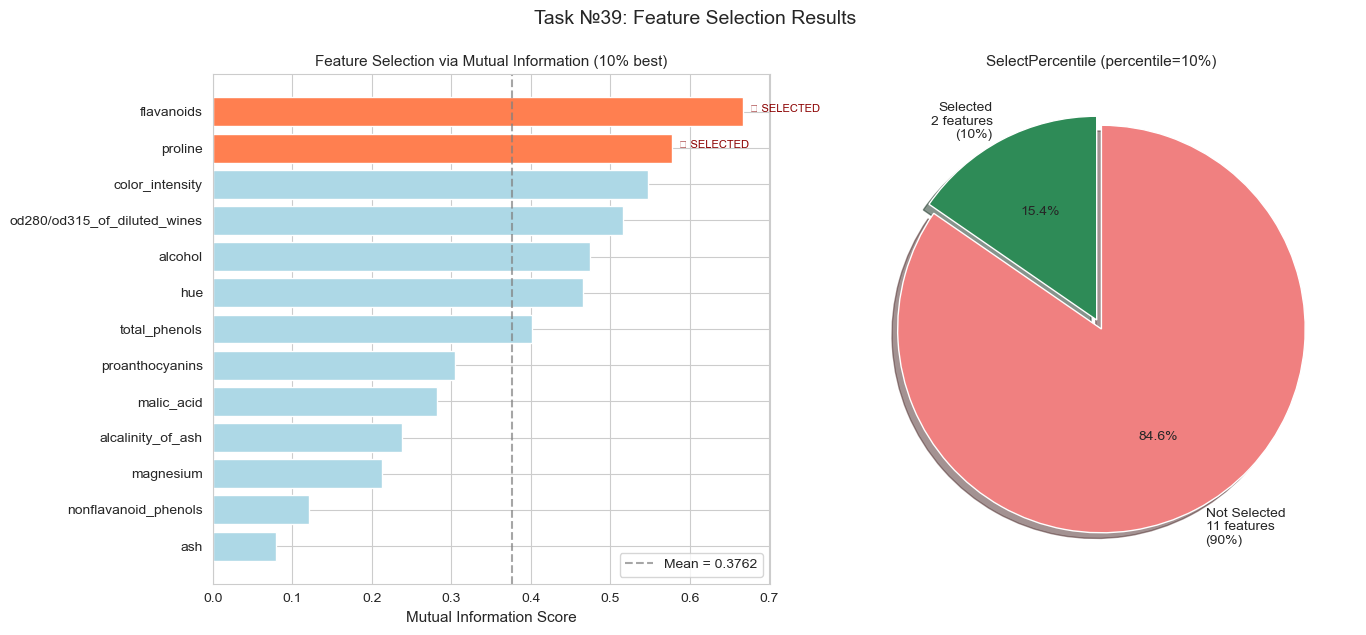


ВЫВОД ПО ЗАДАЧЕ №39 / 任务39结论:
1. Total features: 13 -> Selected: 2 (10%)
   总特征数: 13 -> 已选: 2 (10%)
2. Selected features: flavanoids, proline
   已选特征: flavanoids, proline
3. Mutual Information evaluates dependency between feature and target variable
   互信息评估了特征与目标变量之间的依赖关系
4. Higher MI Score means more informative feature
   互信息得分越高，特征的信息量越大


In [16]:
# ============================================================================
# ВИЗУАЛИЗАЦИЯ РЕЗУЛЬТАТОВ ЗАДАЧИ №39
# VISUALIZATION FOR TASK №39
# ============================================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Chart 1: Horizontal bar chart of MI Score
mi_df_sorted = mi_df.sort_values('MI Score', ascending=True)
colors = ['coral' if feat in selected_features else 'lightblue' 
          for feat in mi_df_sorted['Признак / Feature']]
axes[0].barh(mi_df_sorted['Признак / Feature'], 
             mi_df_sorted['MI Score'], 
             color=colors)
axes[0].set_xlabel('Mutual Information Score', fontsize=11)
axes[0].set_title('Feature Selection via Mutual Information (10% best)', fontsize=11)
axes[0].axvline(x=mi_df_sorted['MI Score'].mean(), 
                linestyle='--', color='gray', alpha=0.7, label=f'Mean = {mi_df_sorted["MI Score"].mean():.4f}')
axes[0].legend()

# Add annotation for selected features
for i, (_, row) in enumerate(mi_df_sorted.iterrows()):
    if row['Признак / Feature'] in selected_features:
        axes[0].annotate('✓ SELECTED', 
                        xy=(row['MI Score'], row['Признак / Feature']),
                        xytext=(5, 0), textcoords='offset points', 
                        fontsize=8, color='darkred')

# Chart 2: Pie chart - ratio of selected vs not selected features
sizes = [n_selected, n_features - n_selected]
labels = [f'Selected\n{n_selected} features\n({percentile}%)',
          f'Not Selected\n{n_features - n_selected} features\n({100-percentile}%)']
colors_pie = ['seagreen', 'lightcoral']
explode = (0.05, 0)

axes[1].pie(sizes, explode=explode, labels=labels, colors=colors_pie,
            autopct='%1.1f%%', shadow=True, startangle=90)
axes[1].set_title(f'SelectPercentile (percentile={percentile}%)', fontsize=11)

plt.tight_layout()
plt.suptitle('Task №39: Feature Selection Results', fontsize=14, y=1.05)
plt.show()

print("\n" + "=" * 60)
print("ВЫВОД ПО ЗАДАЧЕ №39 / 任务39结论:")
print("=" * 60)
print(f"1. Total features: {n_features} -> Selected: {n_selected} (10%)")
print(f"   总特征数: {n_features} -> 已选: {n_selected} (10%)")
print(f"2. Selected features: {', '.join(selected_features)}")
print(f"   已选特征: {', '.join(selected_features)}")
print("3. Mutual Information evaluates dependency between feature and target variable")
print("   互信息评估了特征与目标变量之间的依赖关系")
print("4. Higher MI Score means more informative feature")
print("   互信息得分越高，特征的信息量越大")
print("=" * 60)

In [18]:
# ============================================================================
# ОБЩЕЕ РЕЗЮМЕ РАБОТЫ
# 工作总结
# ============================================================================

print("=" * 70)
print("ИТОГОВОЕ РЕЗЮМЕ / FINAL SUMMARY")
print("=" * 70)
print()
print("📊 ИСПОЛЬЗОВАННЫЙ НАБОР ДАННЫХ / DATASET USED:")
print("   - Name: Wine Dataset")
print("   - 名称: 葡萄酒数据集")
print("   - Number of samples: 178")
print("   - 样本数量: 178")
print("   - Number of features: 13 numerical")
print("   - 特征数量: 13个数值特征")
print("   - Target variable: 3 wine classes")
print("   - 目标变量: 3种葡萄酒类型")
print()
print("=" * 70)
print("✅ ЗАДАЧА №19: Mean Normalisation")
print("✅ TASK №19: Mean Normalisation")
print("=" * 70)
print("   • Feature: 'alcohol'")
print("   • 特征: 'alcohol'（酒精含量）")
print("   • Method: X_norm = (X - mean(X)) / (max(X) - min(X))")
print("   • 方法: X_norm = (X - 均值) / (最大值 - 最小值)")
print("   • Result: data transformed to range [-0.5, 0.5], mean = 0")
print("   • 结果: 数据转换到 [-0.5, 0.5] 范围，均值 = 0")
print()
print("=" * 70)
print("✅ ЗАДАЧА №39: SelectPercentile + Mutual Information")
print("✅ TASK №39: SelectPercentile + Mutual Information")
print("=" * 70)
print(f"   • Method: SelectPercentile (percentile = {percentile}%)")
print(f"   • 方法: SelectPercentile (percentile = {percentile}%)")
print("   • Criterion: Mutual Information")
print("   • 标准: 互信息")
print(f"   • Result: selected {n_selected} out of {n_features} features")
print(f"   • 结果: 从 {n_features} 个特征中选出 {n_selected} 个")
print(f"   • Selected features: {', '.join(selected_features)}")
print(f"   • 已选特征: {', '.join(selected_features)}")
print()
print("=" * 70)
print("📈 ДОПОЛНИТЕЛЬНОЕ ТРЕБОВАНИЕ (ИУ5И-22М):")
print("   ADDITIONAL REQUIREMENT (group ИУ5И-22М):")
print("   • Histogram for feature 'alcohol' was created")
print("   • 已为 'alcohol' 特征构建直方图")
print("   • Histogram for normalized values was created")
print("   • 已为归一化后的值构建直方图")


ИТОГОВОЕ РЕЗЮМЕ / FINAL SUMMARY

📊 ИСПОЛЬЗОВАННЫЙ НАБОР ДАННЫХ / DATASET USED:
   - Name: Wine Dataset
   - 名称: 葡萄酒数据集
   - Number of samples: 178
   - 样本数量: 178
   - Number of features: 13 numerical
   - 特征数量: 13个数值特征
   - Target variable: 3 wine classes
   - 目标变量: 3种葡萄酒类型

✅ ЗАДАЧА №19: Mean Normalisation
✅ TASK №19: Mean Normalisation
   • Feature: 'alcohol'
   • 特征: 'alcohol'（酒精含量）
   • Method: X_norm = (X - mean(X)) / (max(X) - min(X))
   • 方法: X_norm = (X - 均值) / (最大值 - 最小值)
   • Result: data transformed to range [-0.5, 0.5], mean = 0
   • 结果: 数据转换到 [-0.5, 0.5] 范围，均值 = 0

✅ ЗАДАЧА №39: SelectPercentile + Mutual Information
✅ TASK №39: SelectPercentile + Mutual Information
   • Method: SelectPercentile (percentile = 10%)
   • 方法: SelectPercentile (percentile = 10%)
   • Criterion: Mutual Information
   • 标准: 互信息
   • Result: selected 2 out of 13 features
   • 结果: 从 13 个特征中选出 2 个
   • Selected features: flavanoids, proline
   • 已选特征: flavanoids, proline

📈 ДОПОЛНИТЕЛЬНОЕ ТРЕБОВАНИЕ

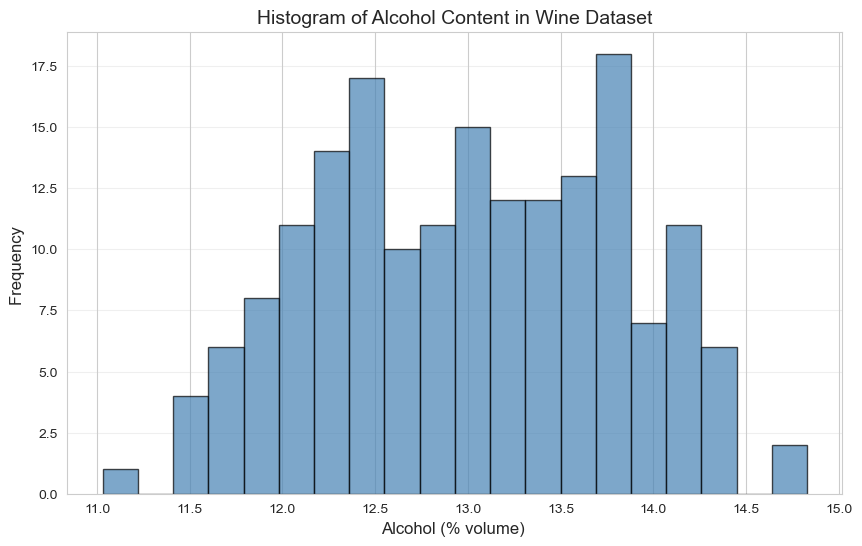

In [20]:
# Специальный код для гистограммы (дополнительное требование)
# 专门用于直方图的代码（额外要求）

import matplotlib.pyplot as plt

# Построение гистограммы для признака 'alcohol'
# 为 'alcohol' 特征构建直方图
plt.figure(figsize=(10, 6))
plt.hist(df['alcohol'], bins=20, color='steelblue', edgecolor='black', alpha=0.7)
plt.title('Histogram of Alcohol Content in Wine Dataset', fontsize=14)
plt.xlabel('Alcohol (% volume) ', fontsize=12)
plt.ylabel('Frequency ', fontsize=12)
plt.grid(axis='y', alpha=0.3)
plt.show()